# Polynomial Regression on Salary Dataset

## 1. Collect Data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dataset = pd.read_csv("Salary_Data.csv")


## 2. Data Preprocessing

### 2.1 Understand the Dataset

In [9]:
dataset.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [11]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [13]:
dataset.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


### 2.2 Check Missing Values

In [16]:
dataset.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

**No missing values found. No preprocessing required.**

### 2.3 Handle Missing Values
No preprocessing required.

### 2.4 Encoding
**Encoding is not required** because all features are numerical.

### 2.5 Split Independent and Dependent Variables

In [22]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

### 2.6 Split Training and Testing Data

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 2.7 Feature Scaling
Feature scaling is **not required** for Polynomial Regression with Linear Regression.

## 3. Model Building
### 3.1 Import Required Libraries

In [28]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

### 3.2 Fit the Model

In [70]:
poly = PolynomialFeatures(degree=5)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)

LinearRegression()

## 4. Test the Model

In [73]:
y_pred = model.predict(X_test_poly)

salary = model.predict(poly.transform([[6.5]]))
print("Predicted Salary:", salary[0])

Predicted Salary: 89741.90275999828


### Visualize Polynomial Regression

C:\Users\CHETAN KUMAR\AppData\Local\Temp\ipykernel_22628\2780001824.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1).reshape(-1,1)


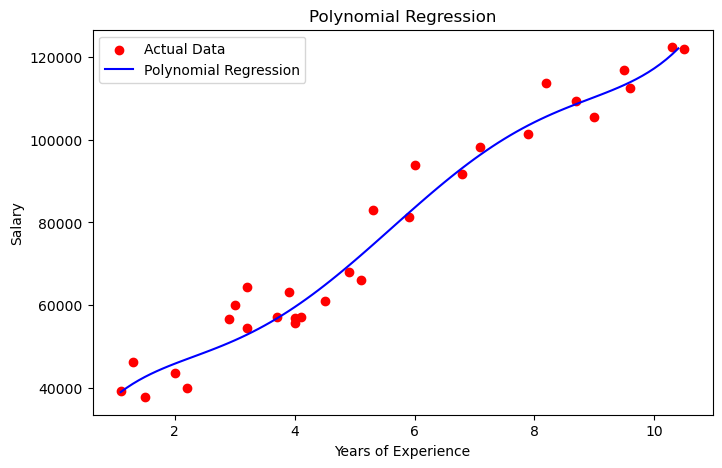

In [76]:
X_grid = np.arange(min(X), max(X), 0.1).reshape(-1,1)

plt.figure(figsize=(8,5))
plt.scatter(X, y, color='red', label='Actual Data')
plt.plot(X_grid,
         model.predict(poly.transform(X_grid)),
         color='blue',
         label='Polynomial Regression')
plt.title("Polynomial Regression")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()
plt.show()

## 5. Evaluation Metrics

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 5952.1581391717
MSE : 49703842.79918429
RMSE: 7050.0952333414825
R2 Score: 0.9026933486383973


### Interpretation

- **MAE:** Average absolute prediction error.
- **MSE:** Average squared prediction error.
- **RMSE:** Square root of MSE; same unit as salary.
- **R² Score:** Measures how well the model explains the variance in salary.
